In [ ]:
'''
from google.cloud import storage


def download_blob(bucket_name, source_blob_name, destination_file_name):
    """Downloads a blob from the bucket."""
    # The ID of your GCS bucket
    # bucket_name = "your-bucket-name"

    # The ID of your GCS object
    # source_blob_name = "storage-object-name"

    # The path to which the file should be downloaded
    # destination_file_name = "local/path/to/file"

    storage_client = storage.Client()

    bucket = storage_client.bucket(bucket_name)

    # Construct a client side representation of a blob.
    # Note `Bucket.blob` differs from `Bucket.get_blob` as it doesn't retrieve
    # any content from Google Cloud Storage. As we don't need additional data,
    # using `Bucket.blob` is preferred here.
    blob = bucket.blob(source_blob_name)
    blob.download_to_filename(destination_file_name)

    print(
        "Downloaded storage object {} from bucket {} to local file {}.".format(
            source_blob_name, bucket_name, destination_file_name
        )
    )
'''

In [ ]:
# OVO SE PRVO POKRECE
categories = [
    "aircraft carrier", "airplane", "alarm clock", "ambulance", "angel", "animal migration",
    "ant", "anvil", "apple", "arm", "asparagus", "axe", "backpack", "banana", "bandage", "barn",
    "baseball", "baseball bat", "basket", "basketball", "bat", "bathtub", "beach", "bear", "beard",
    "bed", "bee", "belt", "bench", "bicycle", "binoculars", "bird", "birthday cake", "blackberry",
    "blueberry", "book", "boomerang", "bottlecap", "bowtie", "bracelet", "brain", "bread", "bridge",
    "broccoli", "broom", "bucket", "bulldozer", "bus", "bush", "butterfly", "cactus", "cake",
    "calculator", "calendar", "camel", "camera", "camouflage", "campfire", "candle", "cannon",
    "canoe", "car", "carrot", "castle", "cat", "ceiling fan", "cello", "cell phone", "chair",
    "chandelier", "church", "circle", "clarinet", "clock", "cloud", "coffee cup", "compass",
    "computer", "cookie", "cooler", "couch", "cow", "crab", "crayon", "crocodile", "crown",
    "cruise ship", "cup", "diamond", "dishwasher", "diving board", "dog", "dolphin", "donut",
    "door", "dragon", "dresser", "drill", "drums", "duck", "dumbbell", "ear", "elbow", "elephant",
    "envelope", "eraser", "eye", "eyeglasses", "face", "fan", "feather", "fence", "finger",
    "fire hydrant", "fireplace", "firetruck", "fish", "flamingo", "flashlight", "flip flops",
    "floor lamp", "flower", "flying saucer", "foot", "fork", "frog", "frying pan", "garden",
    "garden hose", "giraffe", "goatee", "golf club", "grapes", "grass", "guitar", "hamburger",
    "hammer", "hand", "harp", "hat", "headphones", "hedgehog", "helicopter", "helmet", "hexagon",
    "hockey puck", "hockey stick", "horse", "hospital", "hot air balloon", "hot dog", "hot tub",
    "hourglass", "house", "house plant", "hurricane", "ice cream", "jacket", "jail", "kangaroo",
    "key", "keyboard", "knee", "knife", "ladder", "lantern", "laptop", "leaf", "leg", "light bulb",
    "lighter", "lighthouse", "lightning", "line", "lion", "lipstick", "lobster", "lollipop",
    "mailbox", "map", "marker", "matches", "megaphone", "mermaid", "microphone", "microwave",
    "monkey", "moon", "mosquito", "motorbike", "mountain", "mouse", "moustache", "mouth", "mug",
    "mushroom", "nail", "necklace", "nose", "ocean", "octagon", "octopus", "onion", "oven", "owl",
    "paintbrush", "paint can", "palm tree", "panda", "pants", "paper clip", "parachute", "parrot",
    "passport", "peanut", "pear", "peas", "pencil", "penguin", "piano", "pickup truck",
    "picture frame", "pig", "pillow", "pineapple", "pizza", "pliers", "police car", "pond", "pool",
    "popsicle", "postcard", "potato", "power outlet", "purse", "rabbit", "raccoon", "radio",
    "rain", "rainbow", "rake", "remote control", "rhinoceros", "rifle", "river", "roller coaster",
    "rollerskates", "sailboat", "sandwich", "saw", "saxophone", "school bus", "scissors",
    "scorpion", "screwdriver", "sea turtle", "see saw", "shark", "sheep", "shoe", "shorts",
    "shovel", "sink", "skateboard", "skull", "skyscraper", "sleeping bag", "smiley face", "snail",
    "snake", "snorkel", "snowflake", "snowman", "soccer ball", "sock", "speedboat", "spider",
    "spoon", "spreadsheet", "square", "squiggle", "squirrel", "stairs", "star", "steak", "stereo",
    "stethoscope", "stitches", "stop sign", "stove", "strawberry", "streetlight", "string bean",
    "submarine", "suitcase", "sun", "swan", "sweater", "swing set", "sword", "syringe", "table",
    "teapot", "teddy-bear", "telephone", "television", "tennis racquet", "tent", "The Eiffel Tower",
    "The Great Wall of China", "The Mona Lisa", "tiger", "toaster", "toe", "toilet", "tooth",
    "toothbrush", "toothpaste", "tornado", "tractor", "traffic light", "train", "tree", "triangle",
    "trombone", "truck", "trumpet", "t-shirt", "umbrella", "underwear", "van", "vase", "violin",
    "washing machine", "watermelon", "waterslide", "whale", "wheel", "windmill", "wine bottle",
    "wine glass", "wristwatch", "yoga", "zebra", "zigzag"
]


In [2]:
print(len(categories))

345


In [ ]:
# OVO SE DRUGO POKRECE

import os
import requests

# Lista kategorija koje želiš da preuzmeš
'''
categories = [
    "The Eiffel Tower",
    "cat",
    "apple",
    # dodaj ostale po potrebi
]
'''

base_url = "https://storage.googleapis.com/quickdraw_dataset/full/simplified/"

save_folder = "quickdraw_simplified"
os.makedirs(save_folder, exist_ok=True)

for category in categories:
    clean_name = category  # zadrži razmake za sada
    filename = f"full_simplified_{clean_name}.ndjson"
    url_name = category.replace(" ", "%20")
    url = f"{base_url}{url_name}.ndjson"
    save_path = os.path.join(save_folder, filename)

    print(f"Preuzimam: {url} → {save_path}")
    response = requests.get(url)

    if response.status_code == 200:
        with open(save_path, "wb") as f:
            f.write(response.content)
    else:
        print(f"Neuspešno preuzimanje kategorije: {category} (status {response.status_code})")



Preuzimam: https://storage.googleapis.com/quickdraw_dataset/full/simplified/aircraft%20carrier.ndjson → quickdraw_simplified\full_simplified_aircraft carrier.ndjson
Preuzimam: https://storage.googleapis.com/quickdraw_dataset/full/simplified/airplane.ndjson → quickdraw_simplified\full_simplified_airplane.ndjson
Preuzimam: https://storage.googleapis.com/quickdraw_dataset/full/simplified/alarm%20clock.ndjson → quickdraw_simplified\full_simplified_alarm clock.ndjson
Preuzimam: https://storage.googleapis.com/quickdraw_dataset/full/simplified/ambulance.ndjson → quickdraw_simplified\full_simplified_ambulance.ndjson
Preuzimam: https://storage.googleapis.com/quickdraw_dataset/full/simplified/angel.ndjson → quickdraw_simplified\full_simplified_angel.ndjson
Preuzimam: https://storage.googleapis.com/quickdraw_dataset/full/simplified/animal%20migration.ndjson → quickdraw_simplified\full_simplified_animal migration.ndjson
Preuzimam: https://storage.googleapis.com/quickdraw_dataset/full/simplified/an

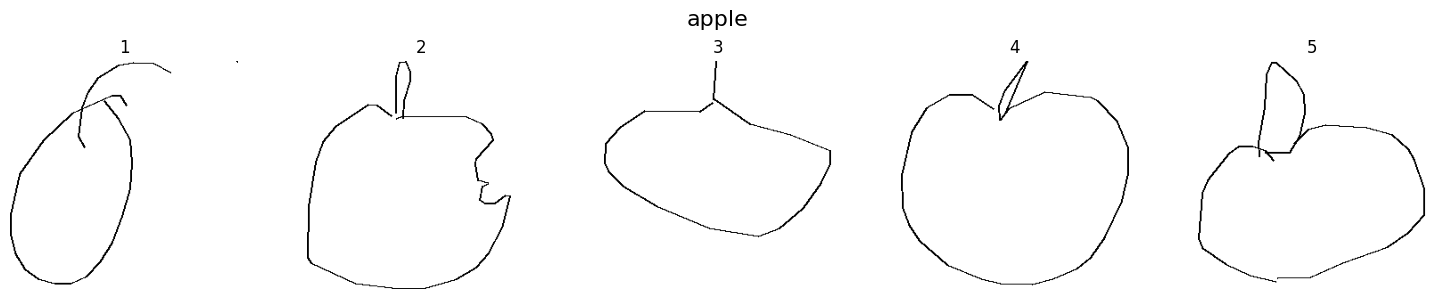

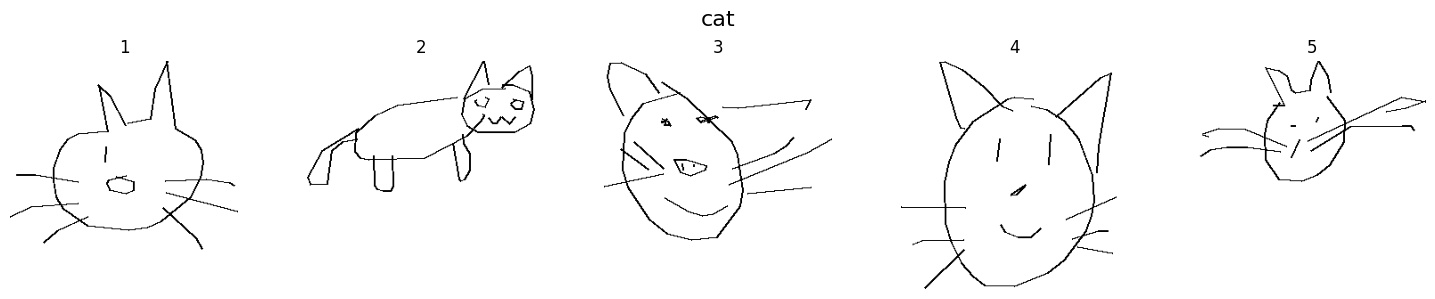

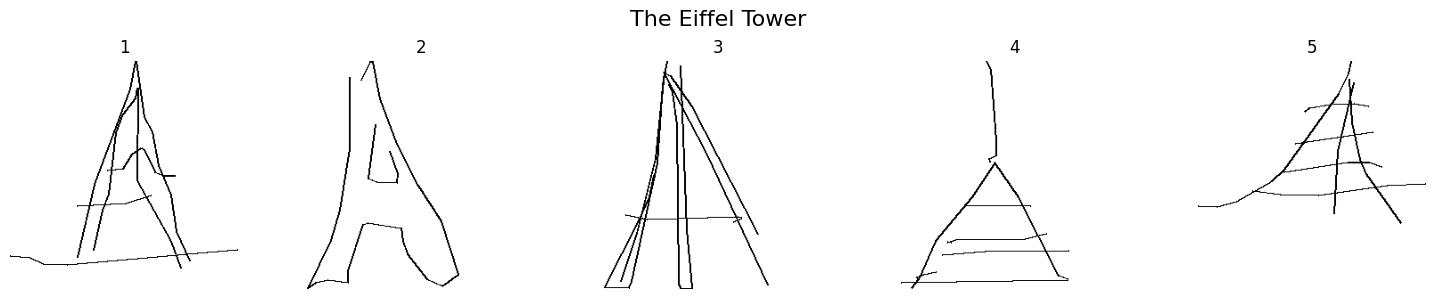

In [4]:
import os
import json
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Putanja do foldera sa .ndjson fajlovima
data_folder = "quickdraw_simplified"
image_size = 256  # Rezolucija slike
drawings_per_category = 5

def draw_quickdraw_strokes(drawing, size=256):
    img = Image.new("L", (size, size), color=255)  # Bela pozadina
    draw = ImageDraw.Draw(img)
    for stroke in drawing:
        if not stroke or len(stroke) != 2:
            continue
        x, y = stroke
        points = list(zip(x, y))
        if len(points) > 1:
            draw.line(points, fill=0, width=max(1, int(size / 128)))
        elif points:
            draw.point(points[0], fill=0)
    return img

# Učitaj sve .ndjson fajlove
files = [f for f in os.listdir(data_folder) if f.endswith(".ndjson")]

for file in files:
    filepath = os.path.join(data_folder, file)
    images = []

    # Učitaj prvih 5 crteža iz fajla
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            if i >= drawings_per_category:
                break
            data = json.loads(line)
            drawing = data.get('drawing', [])
            img = draw_quickdraw_strokes(drawing, size=image_size)
            images.append(img)

    # Prikaži 5 crteža za trenutnu kategoriju
    fig, axes = plt.subplots(1, drawings_per_category, figsize=(drawings_per_category * 3, 3), dpi=100)
    fig.suptitle(file.replace("full_simplified_", "").replace(".ndjson", ""), fontsize=16)

    for idx, (ax, img) in enumerate(zip(axes, images)):
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        ax.set_title(f'{idx + 1}')

    plt.tight_layout()
    plt.show()


In [4]:
import os

folder_path = "quickdraw_simplified"  # putanja do foldera sa .ndjson fajlovima

class_counts = {}

for filename in os.listdir(folder_path):
    if filename.endswith(".ndjson"):
        class_name = filename.removeprefix("full_simplified_").removesuffix(".ndjson")
        file_path = os.path.join(folder_path, filename)
        
        with open(file_path, "r", encoding="utf-8") as f:
            num_drawings = sum(1 for _ in f)
        
        class_counts[class_name] = num_drawings

# Možeš sortirati po abecedi:
sorted_counts = dict(sorted(class_counts.items()))  
# ili po broju crteža (najveći broj prvi):
# sorted_counts = dict(sorted(class_counts.items(), key=lambda item: item[1], reverse=True))

# Ispis rezultata
for class_name, count in sorted_counts.items():
    print(f"{class_name}: {count}")


The Eiffel Tower: 134801
The Great Wall of China: 193015
The Mona Lisa: 121383
aircraft carrier: 116504
airplane: 151623
alarm clock: 123399
ambulance: 148004
angel: 149736
animal migration: 137847
ant: 124612
anvil: 126231
apple: 144722
arm: 120951
asparagus: 168102
axe: 124122
backpack: 125801
banana: 307936
bandage: 147614
barn: 151139
baseball: 135375
baseball bat: 123809
basket: 118458
basketball: 133793
bat: 118114
bathtub: 174336
beach: 124938
bear: 134762
beard: 165202
bed: 113862
bee: 120890
belt: 191119
bench: 128695
bicycle: 126527
binoculars: 124190
bird: 133572
birthday cake: 144982
blackberry: 128153
blueberry: 127878
book: 119364
boomerang: 142682
bottlecap: 153207
bowtie: 130283
bracelet: 119416
brain: 143033
bread: 120570
bridge: 133010
broccoli: 132826
broom: 116927
bucket: 124064
bulldozer: 187409
bus: 166208
bush: 120520
butterfly: 117999
cactus: 131676
cake: 124905
calculator: 128375
calendar: 321981
camel: 121399
camera: 128772
camouflage: 172710
campfire: 133395


In [7]:
min_class = min(class_counts, key=class_counts.get)
max_class = max(class_counts, key=class_counts.get)

print("\n📉 Minimum:")
print(f"{min_class}: {class_counts[min_class]} crteža")

print("\n📈 Maksimum:")
print(f"{max_class}: {class_counts[max_class]} crteža")


📉 Minimum:
panda: 113613 crteža

📈 Maksimum:
snowman: 340029 crteža
